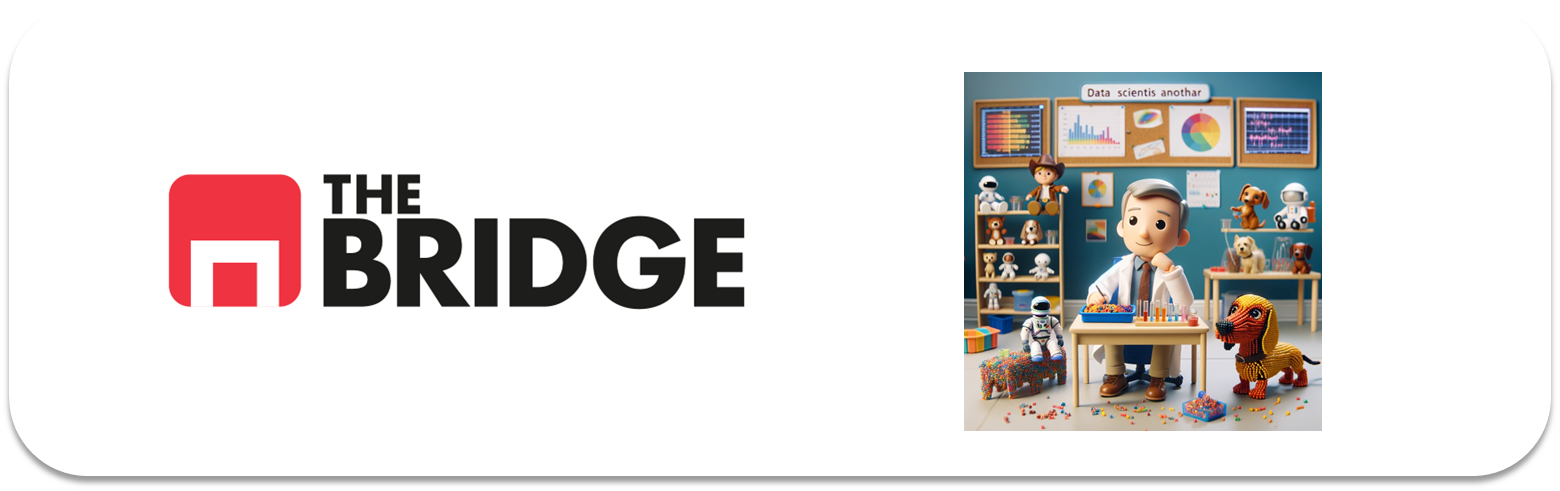

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [9]:

import seaborn as sns

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [10]:
import seaborn as sns

sns.get_dataset_names()

df_titanic = sns.load_dataset("titanic")


### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [11]:
df_titanic.head()

df_titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [12]:
porcentaje_nulos = df_titanic.isnull().mean() * 100
porcentaje_nulos

df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median())
df_titanic['embarked'] = df_titanic['embarked'].fillna(df_titanic['embarked'].mode()[0])
df_titanic['embark_town'] = df_titanic['embark_town'].fillna(df_titanic['embark_town'].mode()[0])

df_titanic = df_titanic.drop(columns=['deck'])
df_titanic = df_titanic.drop(columns=['parch'])

df_titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| -       | - |



| **Columna/Variable** | **Descripción** |
|----------------------|-----------------|
| **survived**         | Indica si el pasajero sobrevivió (1) o no (0). |
| **pclass**           | Clase del pasaje (1ª, 2ª, 3ª). |
| **sex**              | Género del pasajero. |
| **age**              | Edad del pasajero. |
| **sibsp**            | Número de familiares (hermanos/as o cónyuge) que viajan con el pasajero. |
| **parch**            | Número de padres/hijos a bordo. |
| **fare**             | Tarifa pagada por el pasajero. |
| **embarked**         | Letra del puerto de embarque (C = Cherbourg; Q = Queenstown; S = Southampton). |
| **class**            | Clase del pasaje como categoría (Primera, Segunda, Tercera). |
| **who**              | Categoría del pasajero (hombre, mujer, niño). |
| **adult_male**       | Booleano que indica si el pasajero es un hombre adulto. |
| **deck**             | Cubierta del barco donde se ubicaba el pasajero. |
| **embark_town**      | Ciudad del puerto de embarque (Cherbourg; Queenstown; Southampton). |
| **alive**            | Indica si el pasajero está vivo ('yes') o muerto ('no'). |
| **alone**            | Booleano que indica si el pasajero viajaba solo. |

### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [13]:
mapa_embarked = {
    'S': 'Southampton',
    'C': 'Cherbourg',
    'Q': 'Queenstown'
}

df_titanic['embarked'] = df_titanic['embarked'].map(mapa_embarked)

df_titanic[['embarked']].head()

,embarked
0,Southampton
1,Cherbourg
2,Southampton
3,Southampton
4,Southampton


### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

In [14]:
lista_variable=["survived","who","age","fare","class","embarked","alone"]

In [16]:
def card_tipo(df, umbral_categoria = 10, umbral_continua = 30):

    # Primera parte: Preparo el dataset con cardinalidades, % variación cardinalidad, y tipos

    df_temp = pd.DataFrame([df.nunique(), df.nunique()/len(df) * 100, df.dtypes]) # Cardinaliad y porcentaje de variación de cardinalidad

    df_temp = df_temp.T # Como nos da los valores de las columnas en columnas, y quiero que estas sean filas, la traspongo

    df_temp = df_temp.rename(columns = {0: "Card", 1: "%_Card", 2: "Tipo"}) # Cambio el nombre de la transposición anterior para que tengan más sentido, y uso asignación en vez de inplace = True (esto es arbitrario para el tamaño de este dataset)

    # Corrección para cuando solo tengo un valor

    df_temp.loc[df_temp.Card == 1, "%_Card"] = 0.00

    # Creo la columna de sugerenica de tipo de variable, empiezo considerando todas categóricas pero podría haber empezado por cualquiera, siempre que adapte los filtros siguientes de forma correspondiente

    df_temp["tipo_sugerido"] = "Categorica"

    df_temp.loc[df_temp["Card"] == 2, "tipo_sugerido"] = "Binaria"

    df_temp.loc[df_temp["Card"] >= umbral_categoria, "tipo_sugerido"] = "Numerica discreta"

    df_temp.loc[df_temp["%_Card"] >= umbral_continua, "tipo_sugerido"] = "Numerica continua"

    # Ojo los filtros aplicados cumplen con el enunciado pero no siguen su orden y planteamiento

    return df_temp

In [18]:
card_tipo(df_titanic,10,25)

,Card,%_Card,Tipo,tipo_sugerido
survived,2,0.224467,int64,Binaria
pclass,3,0.3367,int64,Categorica
sex,2,0.224467,object,Binaria
age,88,9.876543,float64,Numerica discreta
sibsp,7,0.785634,int64,Categorica
fare,248,27.833895,float64,Numerica continua
embarked,3,0.3367,object,Categorica
class,3,0.3367,category,Categorica
who,3,0.3367,object,Categorica
adult_male,2,0.224467,bool,Binaria


In [24]:
categoricas=["alive","who","class","embarked","alone","sex"]
numericas=["fare","age"]

### #2.1 Categóricas

In [32]:
def pinta_distribucion_categoricas(df, columnas_categoricas, relativa=False, mostrar_valores=False):
    num_columnas = len(columnas_categoricas)
    num_filas = (num_columnas // 2) + (num_columnas % 2)

    fig, axes = plt.subplots(num_filas, 2, figsize=(15, 5 * num_filas))
    axes = axes.flatten()

    for i, col in enumerate(columnas_categoricas):
        ax = axes[i]

        serie = df[col].value_counts(dropna=False)
        if relativa:
            serie = serie / serie.sum()

        datos = serie.reset_index()
        datos.columns = [col, 'valor']

        sns.barplot(
            data=datos,
            x=col,
            y='valor',
            ax=ax,
            palette='viridis'
        )

        ax.set_ylabel('Frecuencia Relativa' if relativa else 'Frecuencia')
        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

        if mostrar_valores:
            for p in ax.patches:
                height = p.get_height()
                ax.annotate(
                    f'{height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center',
                    va='center',
                    xytext=(0, 9),
                    textcoords='offset points'
                )

    for j in range(i + 1, num_filas * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


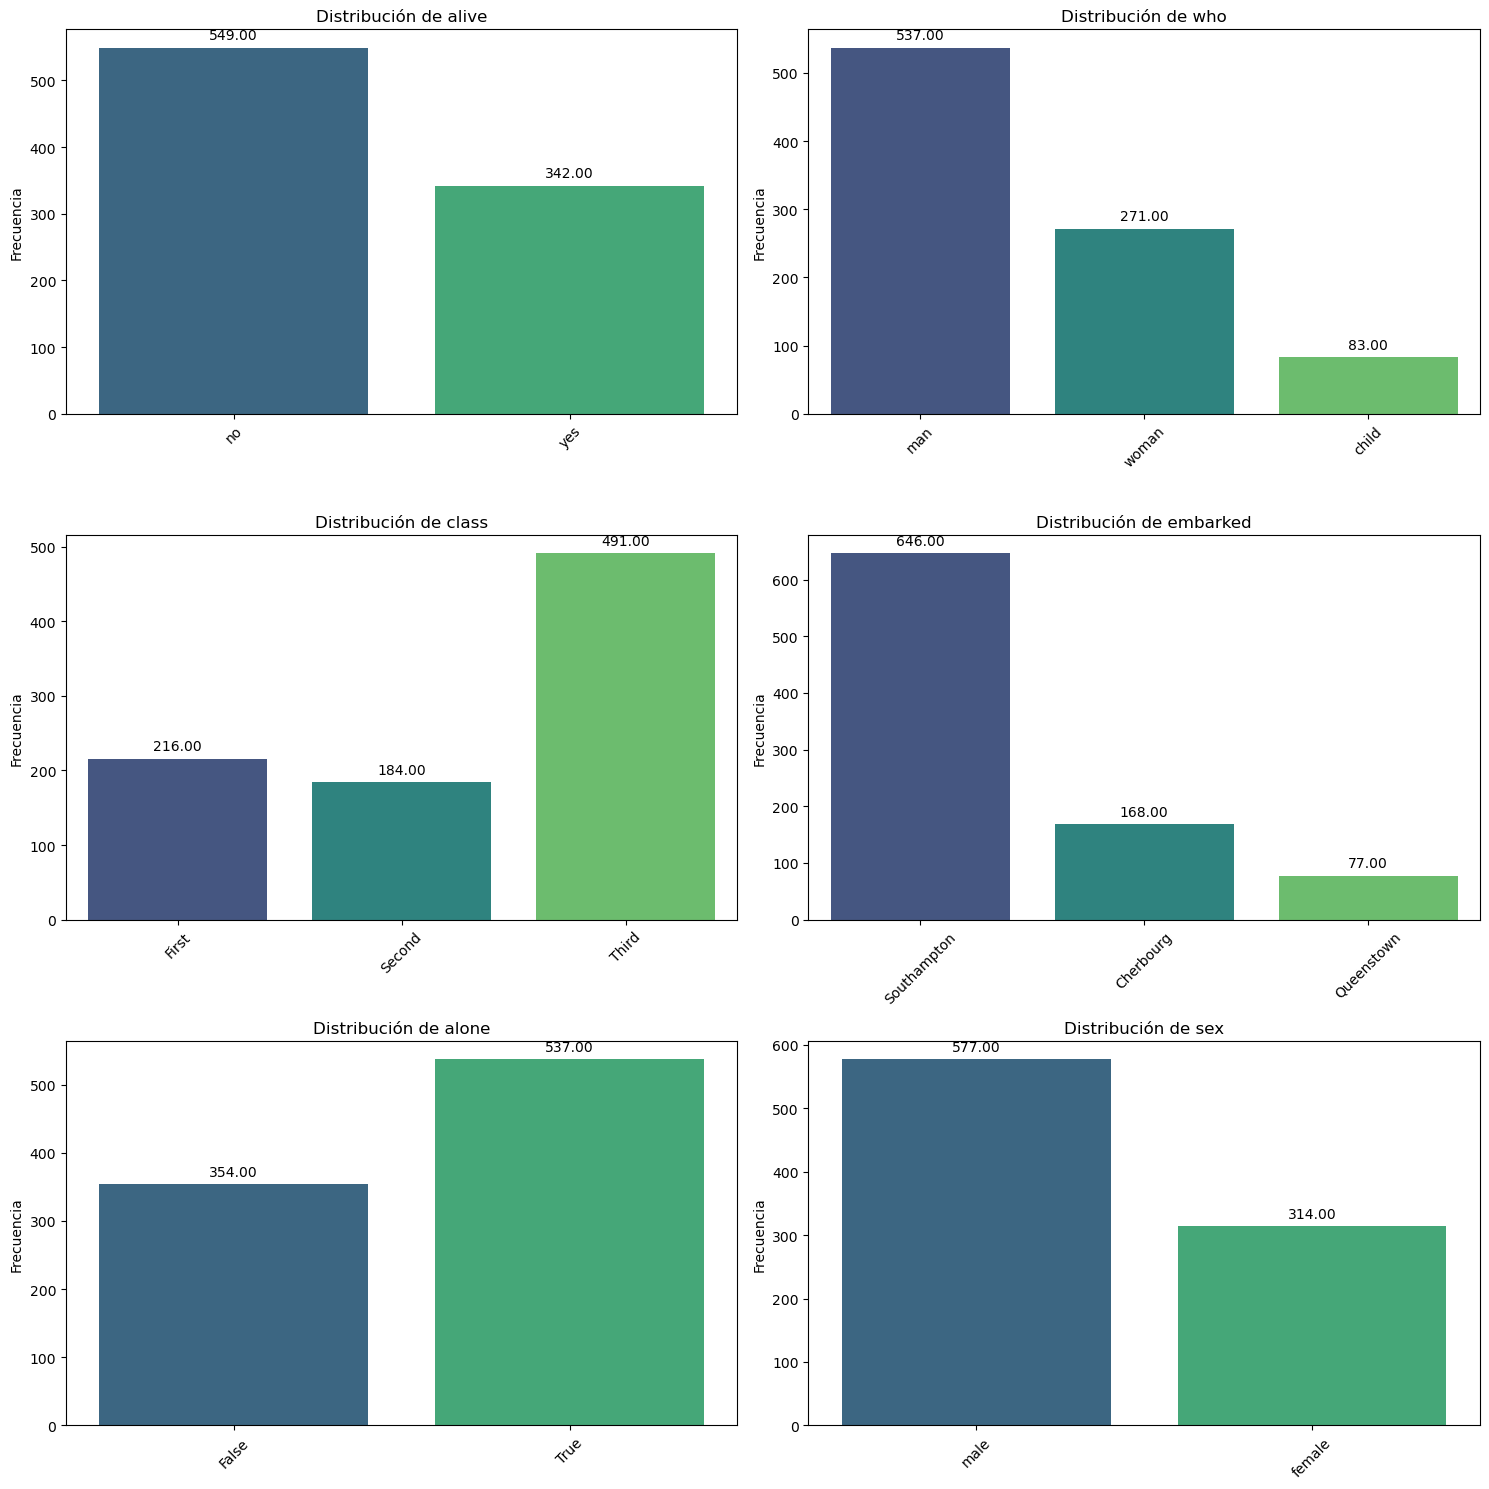

In [33]:
pinta_distribucion_categoricas(df_titanic,categoricas,mostrar_valores=True)

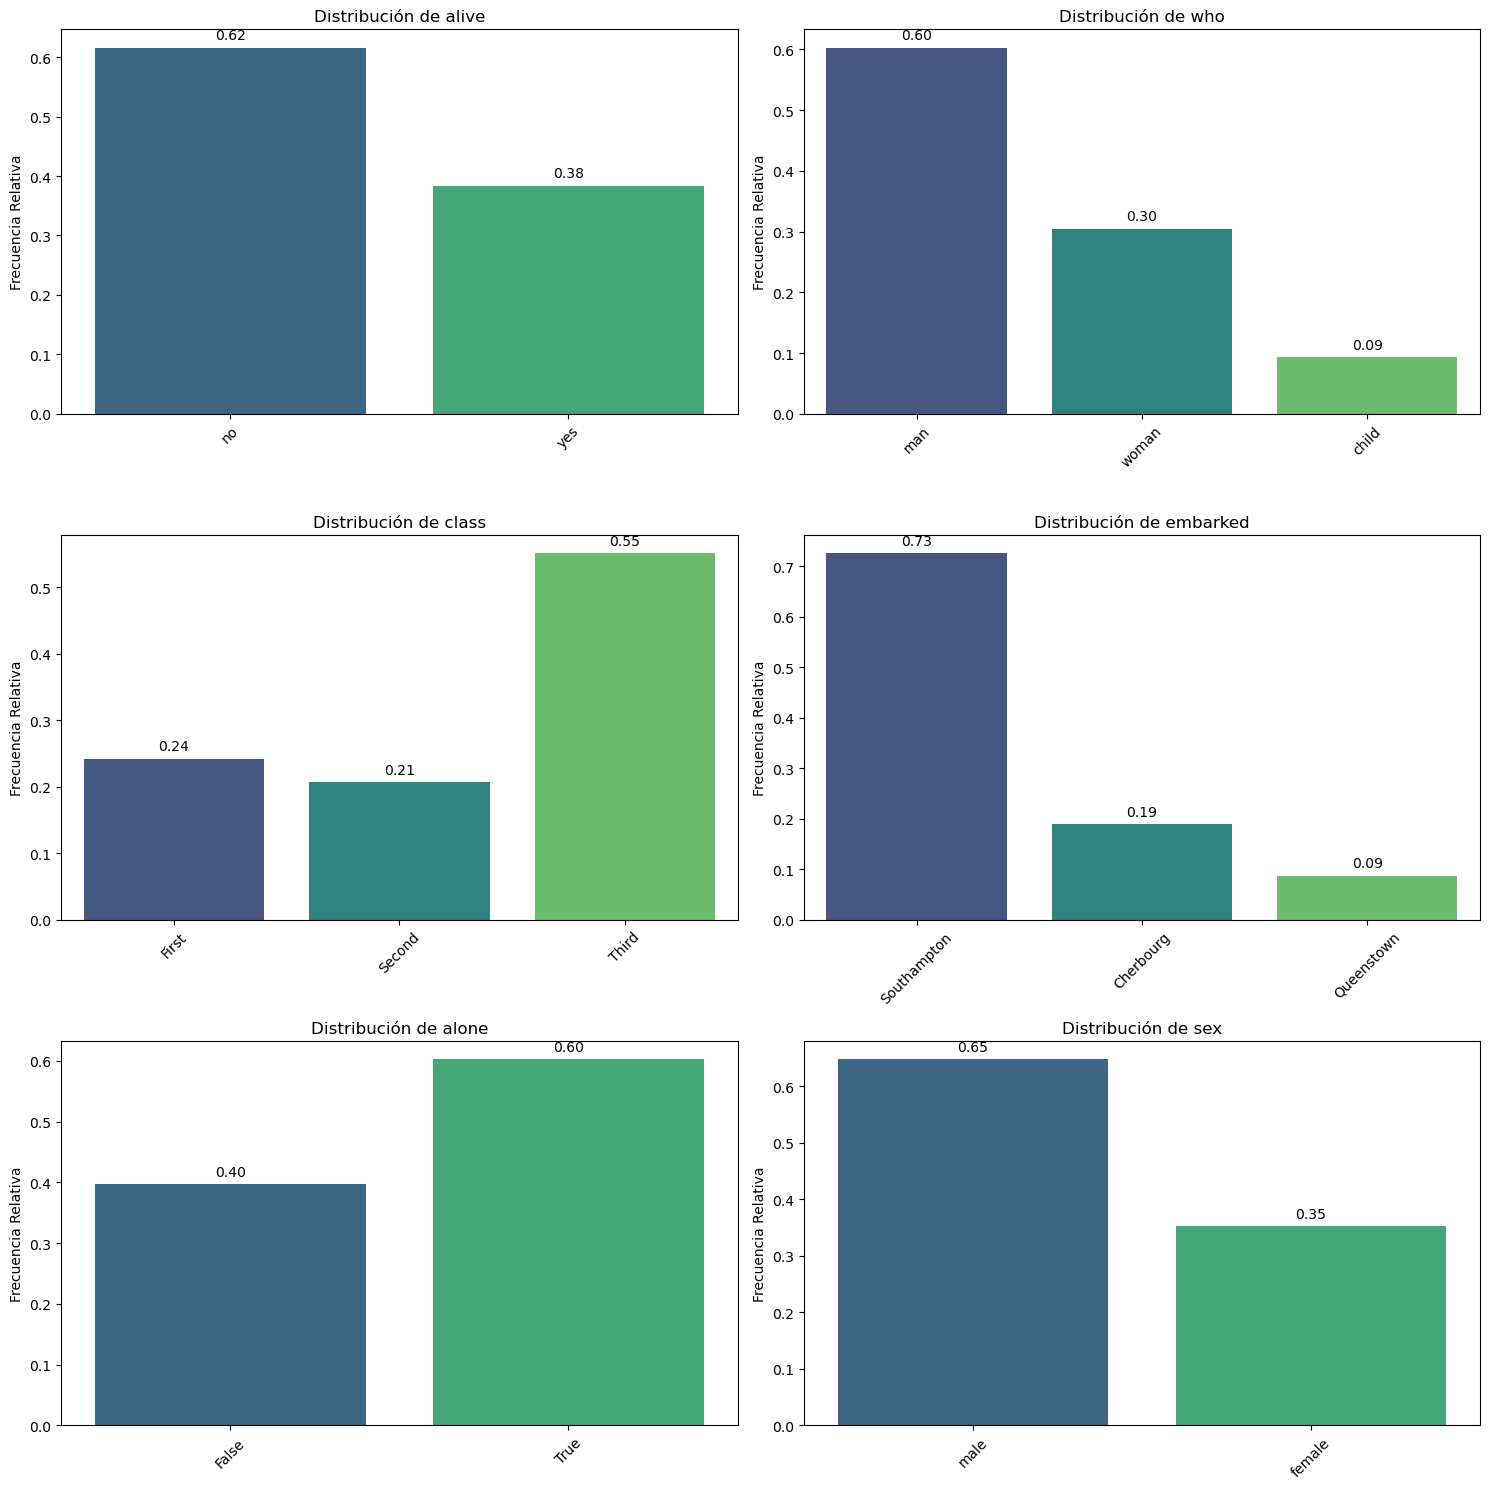

In [34]:
pinta_distribucion_categoricas(df_titanic,categoricas,relativa=True,mostrar_valores=True)

### #2.2 Numéricas

In [35]:
df_titanic[["age","fare"]].describe()

,age,fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


<Axes: >

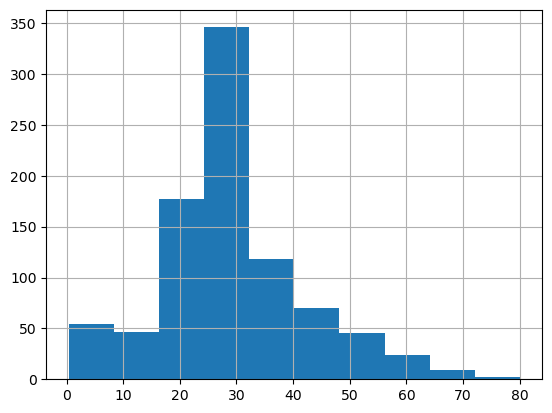

In [36]:
df_titanic["age"].hist()

In [37]:
def get_CV(df,columna):
    columna=[columna] if type(columna)==str else columna
    return df[columna].describe().T["std"]/df[columna].describe().T["mean"]*100

In [38]:
get_CV(df_titanic,"age")

age    44.342625
dtype: float64

In [39]:
get_CV(df_titanic,"fare")

fare    154.307253
dtype: float64

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_combined_graphs(df, columnas, whisker_width=1.5, bins=30):
    num_cols = len(columnas)
    fig, axes = plt.subplots(num_cols, 2, figsize=(14, 4 * num_cols))

    if num_cols == 1:
        axes = [axes]

    for i, col in enumerate(columnas):
        sns.histplot(df[col].dropna(), bins=bins, kde=False, ax=axes[i][0], color='steelblue')
        axes[i][0].set_title(f'Histograma de {col}')
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel('Frecuencia')

        sns.boxplot(x=df[col].dropna(), ax=axes[i][1], width=whisker_width, color='lightgreen')
        axes[i][1].set_title(f'Boxplot de {col}')
        axes[i][1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


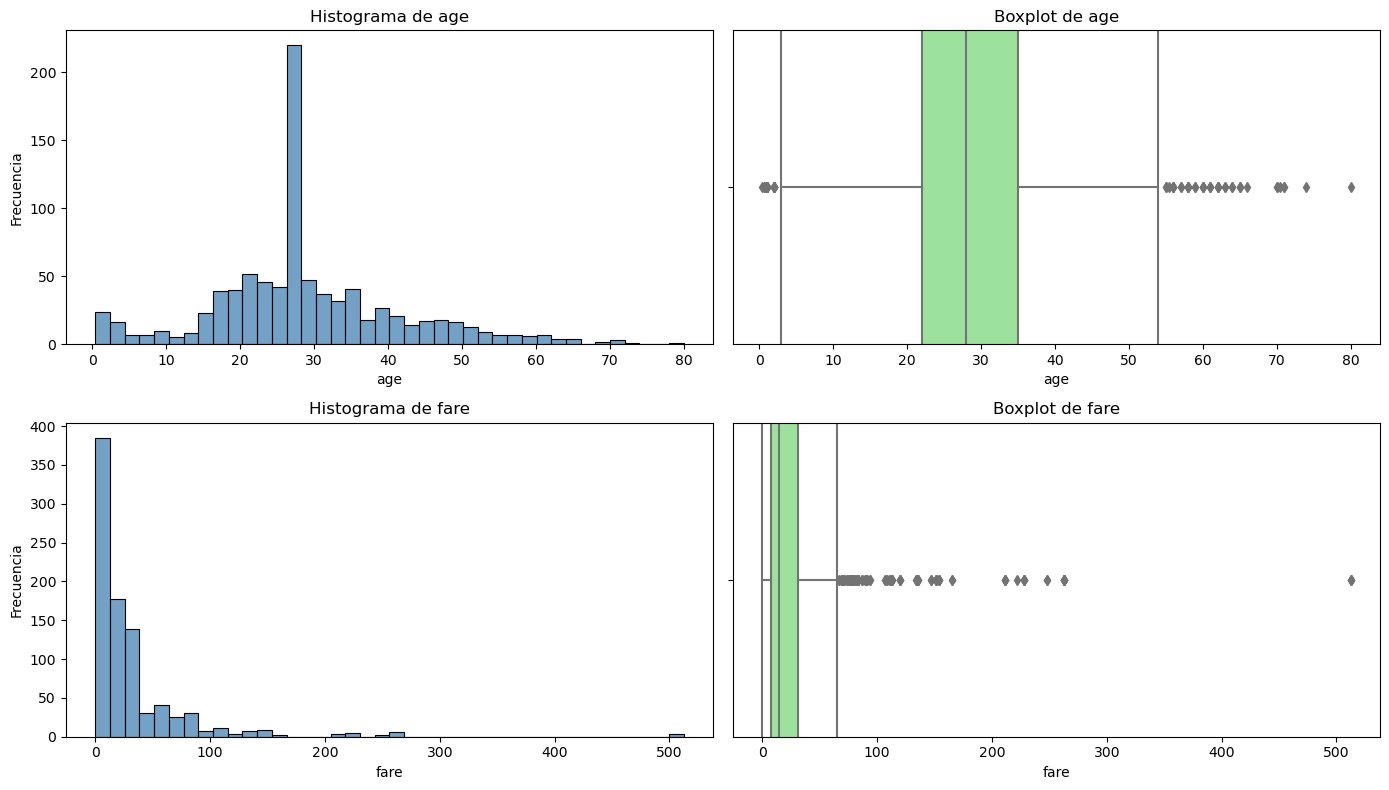

In [45]:
plot_combined_graphs(df_titanic, ["age", "fare"], whisker_width=3, bins=40)
